In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# --- 1. UPLOAD AND LOAD DATASET ---

In [33]:
# --- 1. LOAD DATA ---
file_path = 'socialmedia_data.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print('Dataset Loaded Successfully.\n')
else:
    print(f"Error: '{file_path}' not found.")
    print("Please, Upload the CSV file to your Colab Workspace using the Panel on the Left!!")
    # Stop execution if file isn't found
    import sys
    sys.exit()

Dataset Loaded Successfully.



# --- 2. DATA CLEANING ---

In [20]:
# --- 2. DATA CLEANING ---
print('--- DATA CLEANING ---')
print('Missing values:')
print(df.isnull().sum())
df = df.drop_duplicates(subset=['User_ID'])
print('\nDuplicates removed. Remaining rows:', len(df))
print('Cleaning done. Final shape:', df.shape, '\n')

--- DATA CLEANING ---
Missing values:
User_ID                         0
Age                             0
Gender                          0
Occupation                      0
Device_Type                     0
Daily_Phone_Hours               0
Social_Media_Hours              0
Work_Productivity_Score         0
Sleep_Hours                     0
Stress_Level                    0
App_Usage_Count                 0
Caffeine_Intake_Cups            0
Weekend_Screen_Time_Hours       0
High Stress                     0
Estimated Weekly Screen Time    0
dtype: int64

Duplicates removed. Remaining rows: 50000
Cleaning done. Final shape: (50000, 15) 



# --- 3. FEATURE ENGINEERING ---

In [22]:
# --- 3. FEATURE ENGINEERING ---
print('--- FEATURE ENGINEERING ---')
# Categorize Stress Level (High Stress if >= 7)
df['High Stress'] = df['Stress_Level'].apply(lambda x: 'Yes' if x >= 7 else 'No')
# Total Weekly Screen Time Estimate
df['Estimated Weekly Screen Time'] = (df['Daily_Phone_Hours'] * 5) + (df['Weekend_Screen_Time_Hours'] * 2)
print('New columns added: [High Stress, Estimated Weekly Screen Time]\n')
print(df[['High Stress', 'Estimated Weekly Screen Time']].head(), '\n')

--- FEATURE ENGINEERING ---
New columns added: [High Stress, Estimated Weekly Screen Time]

  High Stress  Estimated Weekly Screen Time
0          No                          23.9
1          No                          16.2
2          No                          39.1
3          No                          54.6
4          No                          59.3 



# --- 4. BASIC EDA - DATA SUMMARY ---

In [23]:
# --- 4. BASIC EDA SUMMARY ---
print('--- SOCIAL MEDIA & SCREEN TIME SUMMARY ---')
print(f"Total Users Analyzed       : {len(df)}")
print(f"Average Daily Phone Hours  : {round(df['Daily_Phone_Hours'].mean(), 2)}")
print(f"Average Social Media Hours : {round(df['Social_Media_Hours'].mean(), 2)}")
print(f"Average Sleep Hours        : {round(df['Sleep_Hours'].mean(), 2)}")
print(f"Average Productivity Score : {round(df['Work_Productivity_Score'].mean(), 2)}\n")

--- SOCIAL MEDIA & SCREEN TIME SUMMARY ---
Total Users Analyzed       : 50000
Average Daily Phone Hours  : 6.51
Average Social Media Hours : 4.27
Average Sleep Hours        : 6.5
Average Productivity Score : 5.5



# --- 5. USAGE BY OCCUPATION ---

In [24]:
# --- 5. USAGE BY OCCUPATION & GENDER ---
print('--- AVG DAILY PHONE HOURS BY OCCUPATION ---')
occ_usage = df.groupby('Occupation')['Daily_Phone_Hours'].mean().sort_values(ascending=False)
print(occ_usage)
print(f'\nHighest usage: {occ_usage.idxmax()}\n')

print('--- AVG DAILY PHONE HOURS BY GENDER ---')
print(df.groupby('Gender')['Daily_Phone_Hours'].mean(), '\n')

print('--- AVG SLEEP HOURS BY STRESS LEVEL ---')
print(df.groupby('High Stress')['Sleep_Hours'].mean(), '\n')

--- AVG DAILY PHONE HOURS BY OCCUPATION ---
Occupation
Business Owner    6.541825
Freelancer        6.514675
Student           6.491052
Professional      6.489294
Name: Daily_Phone_Hours, dtype: float64

Highest usage: Business Owner

--- AVG DAILY PHONE HOURS BY GENDER ---
Gender
Female    6.509989
Male      6.522696
Other     6.494583
Name: Daily_Phone_Hours, dtype: float64 

--- AVG SLEEP HOURS BY STRESS LEVEL ---
High Stress
No     6.489644
Yes    6.509945
Name: Sleep_Hours, dtype: float64 



# --- 6. VISUALIZATIONS ---

# --- Plot 1: Occupation Usage ---

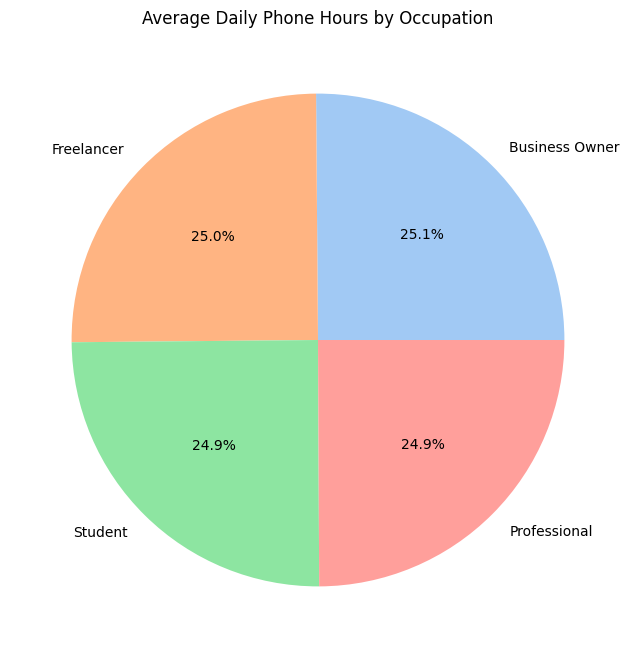

In [26]:
plt.figure(figsize=(8, 8))
plt.pie(occ_usage.values, labels=occ_usage.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Average Daily Phone Hours by Occupation')
plt.show()

# --- Plot 2: Device Distribution ---

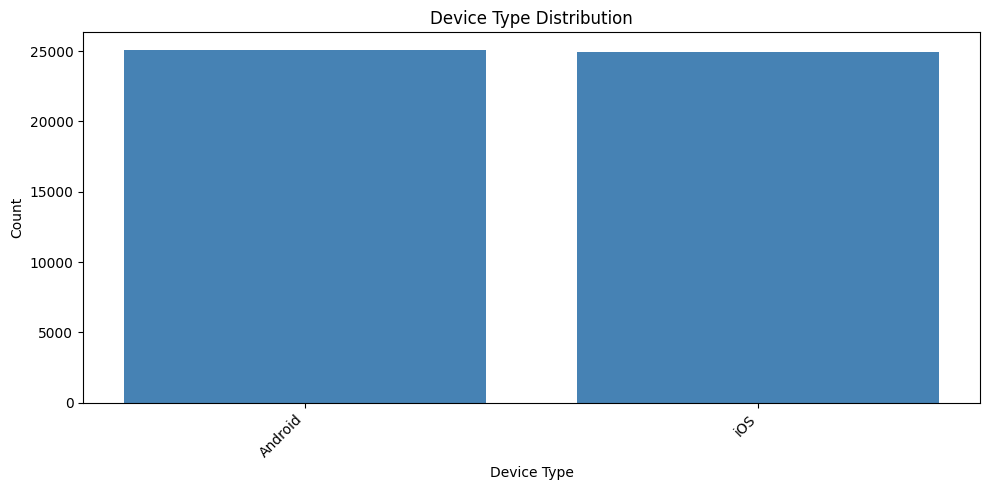

In [27]:
device_counts = df['Device_Type'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(device_counts.index, device_counts.values, color='steelblue')
plt.title('Device Type Distribution')
plt.xlabel('Device Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Plot 3: Age Trend ---

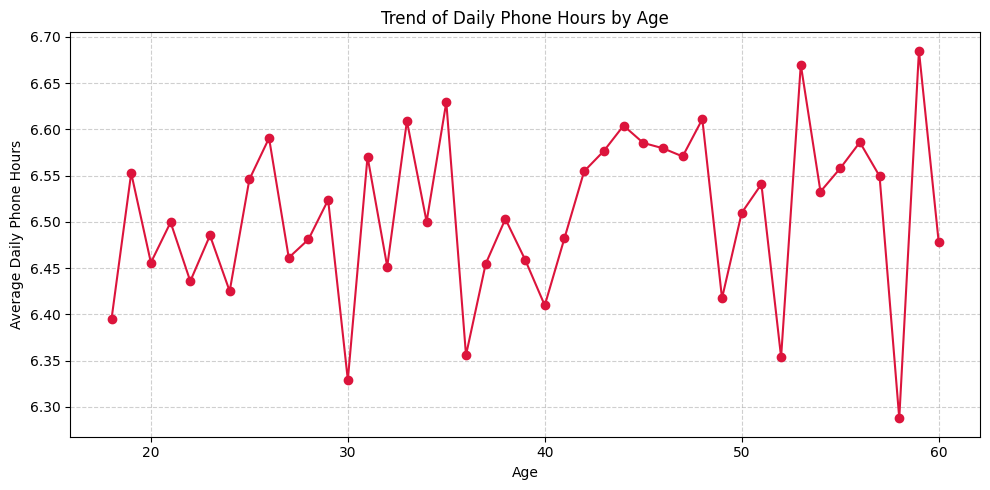

In [28]:
age_usage = df.groupby('Age')['Daily_Phone_Hours'].mean().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(age_usage['Age'], age_usage['Daily_Phone_Hours'], marker='o', color='crimson')
plt.title('Trend of Daily Phone Hours by Age')
plt.xlabel('Age')
plt.ylabel('Average Daily Phone Hours')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Plot 4: Correlation Heatmap ---

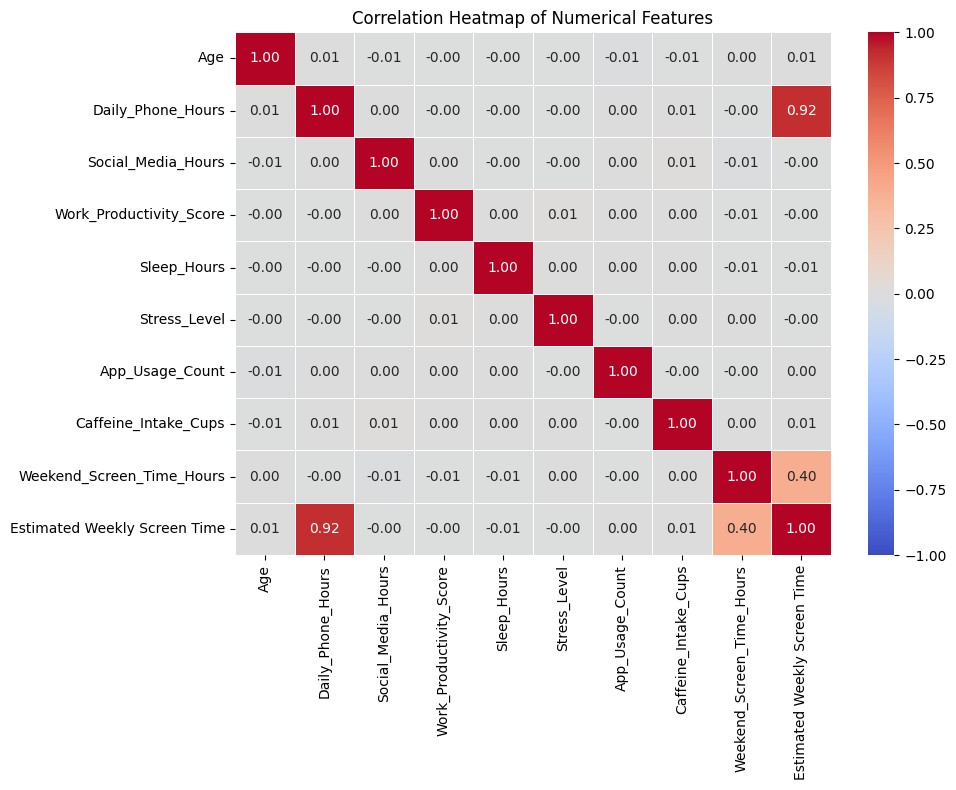

In [ ]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

# --- 7. REGRESSION ANALYSIS ---

In [31]:
print('\n--- REGRESSION ANALYSIS (Predicting Daily Phone Hours) ---')
reg_data = df.copy()

# Preprocessing: Encode categorical features
le = LabelEncoder()
reg_data['Gender'] = le.fit_transform(reg_data['Gender'])
reg_data['Occupation'] = le.fit_transform(reg_data['Occupation'])
reg_data['Device_Type'] = le.fit_transform(reg_data['Device_Type'])

features = ['Age', 'Gender', 'Occupation', 'Social_Media_Hours', 'Sleep_Hours', 'Stress_Level']
X_reg = reg_data[features]
y_reg = reg_data['Daily_Phone_Hours']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

model_reg = LinearRegression()
model_reg.fit(X_train_r, y_train_r)

y_pred_r = model_reg.predict(X_test_r)
print(f"Mean Squared Error : {round(mean_squared_error(y_test_r, y_pred_r), 4)}")
print(f"R-squared Score   : {round(r2_score(y_test_r, y_pred_r), 4)}")

print('\nModel Coefficients:')
for feature, coef in zip(features, model_reg.coef_):
    print(f'{feature}: {round(coef, 4)}')


--- REGRESSION ANALYSIS (Predicting Daily Phone Hours) ---
Mean Squared Error : 10.1791
R-squared Score   : -0.0009

Model Coefficients:
Age: 0.0017
Gender: -0.0257
Occupation: -0.0094
Social_Media_Hours: -0.0048
Sleep_Hours: -0.0108
Stress_Level: -0.002


# --- 8. CLASSIFICATION TASK ---


--- CLASSIFICATION TASK (Predicting High Stress) ---
Model Accuracy: 56.22%

Classification Report:
                   precision    recall  f1-score   support

  Low Stress (No)       0.60      0.82      0.69      5966
High Stress (Yes)       0.40      0.18      0.25      4034

         accuracy                           0.56     10000
        macro avg       0.50      0.50      0.47     10000
     weighted avg       0.52      0.56      0.51     10000



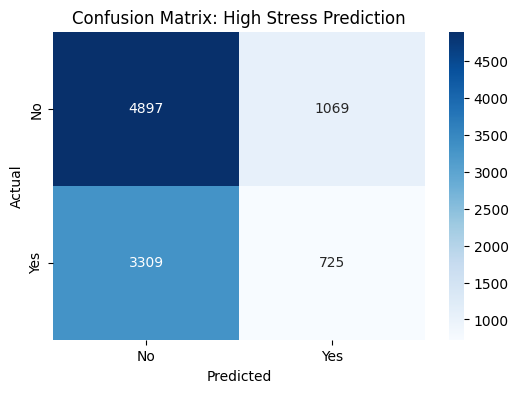

In [32]:
print('\n--- CLASSIFICATION TASK (Predicting High Stress) ---')
clf_data = df.copy()

clf_data['Gender'] = le.fit_transform(clf_data['Gender'])
clf_data['Occupation'] = le.fit_transform(clf_data['Occupation'])
clf_data['Device_Type'] = le.fit_transform(clf_data['Device_Type'])
clf_data['High Stress Label'] = le.fit_transform(clf_data['High Stress']) # No -> 0, Yes -> 1

features_clf = ['Age', 'Gender', 'Occupation', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Sleep_Hours']
X_clf = clf_data[features_clf]
y_clf = clf_data['High Stress Label']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

model_clf = RandomForestClassifier(n_estimators=100, random_state=42)
model_clf.fit(X_train_c, y_train_c)

y_pred_c = model_clf.predict(X_test_c)
print(f'Model Accuracy: {round(accuracy_score(y_test_c, y_pred_c) * 100, 2)}%')
print('\nClassification Report:')
print(classification_report(y_test_c, y_pred_c, target_names=['Low Stress (No)', 'High Stress (Yes)']))

cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix: High Stress Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()